<a href="https://colab.research.google.com/github/aash1808/CodeAlpha_ProjectName/blob/main/task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Unemployment in India.csv')
display(df.head())

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [32]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


None

In [33]:
display(df.isnull().sum())

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [44]:
df.columns = df.columns.str.strip()
df.dropna(inplace=True)

# Ensure 'Date' column is handled only if it's not already datetime
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    # Only strip if it's a string/object type
    if pd.api.types.is_object_dtype(df['Date']):
        df['Date'] = df['Date'].str.strip()
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y') # Corrected indentation

# Drop 'Frequency' and 'Area' columns only if they exist
columns_to_drop = ['Frequency', 'Area']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_columns_to_drop:
    df.drop(columns=existing_columns_to_drop, inplace=True)

display(df.head())

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68


In [45]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 5 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Estimated Unemployment Rate (%)          740 non-null    float64       
 3   Estimated Employed                       740 non-null    float64       
 4   Estimated Labour Participation Rate (%)  740 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 34.7+ KB


None

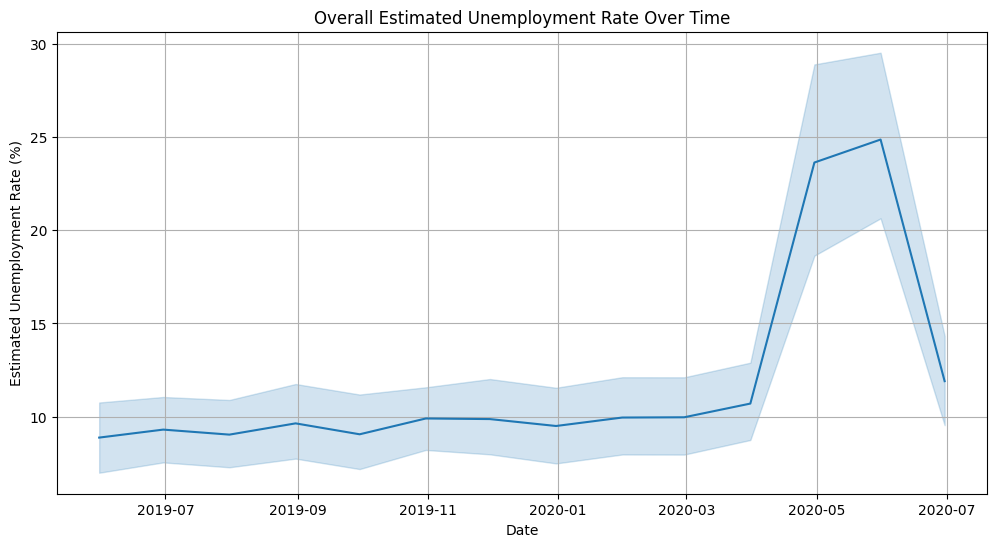

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)')
plt.title('Overall Estimated Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.show()

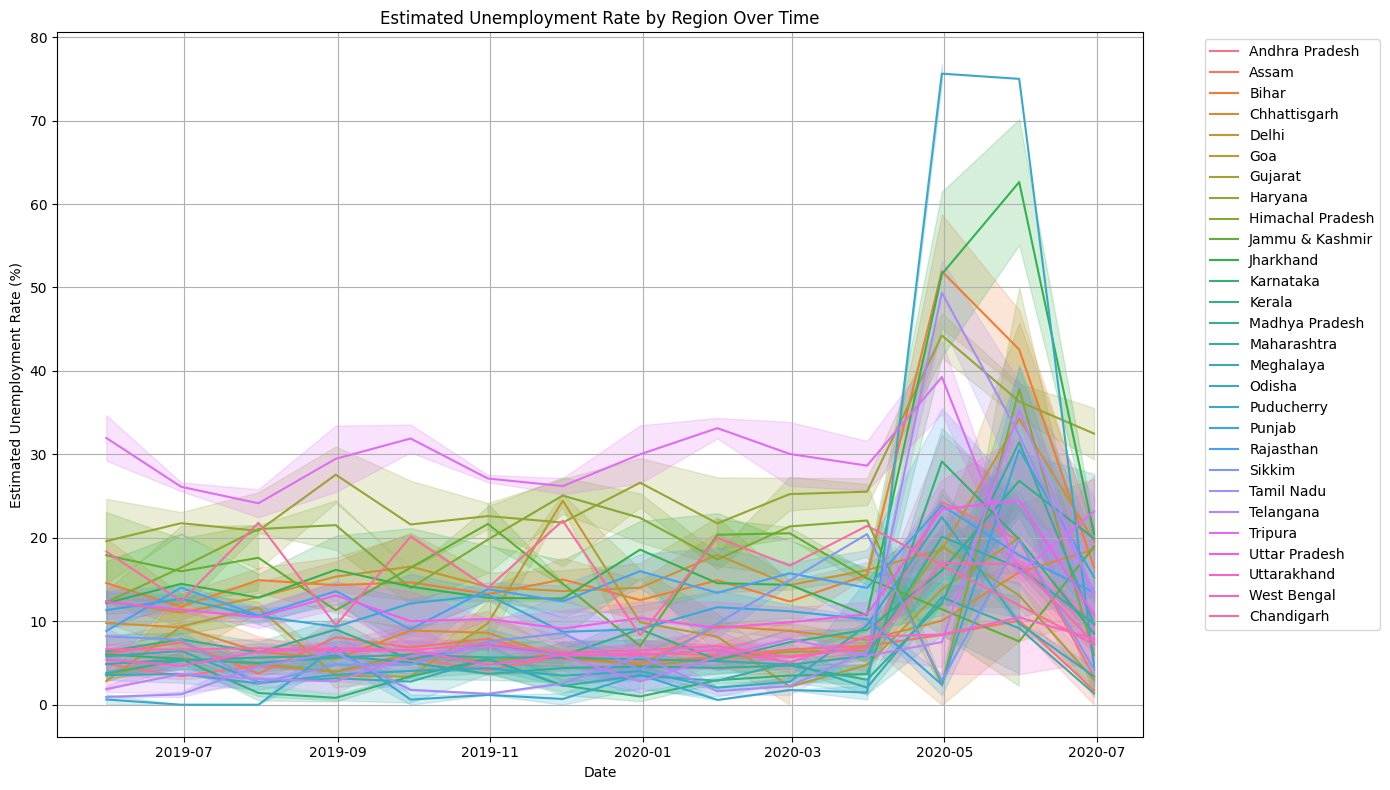

In [17]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Region')
plt.title('Estimated Unemployment Rate by Region Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

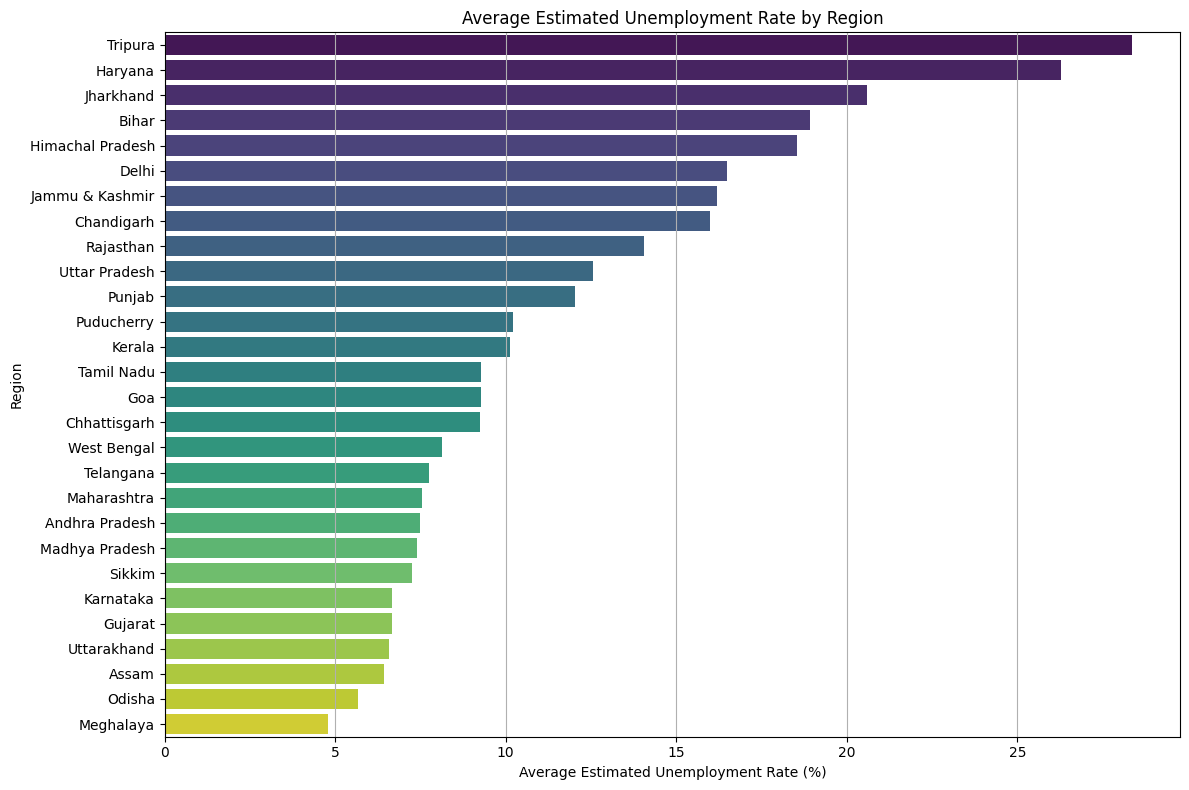

In [24]:
avg_unemployment_region = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=avg_unemployment_region.values, y=avg_unemployment_region.index, hue=avg_unemployment_region.index, palette='viridis', legend=False)
plt.title('Average Estimated Unemployment Rate by Region')
plt.xlabel('Average Estimated Unemployment Rate (%)')
plt.ylabel('Region')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

,Estimated Unemployment Rate (%)
Period,
Pre-Lockdown,9.509534
Lockdown,19.680455
Post-Lockdown,11.903600


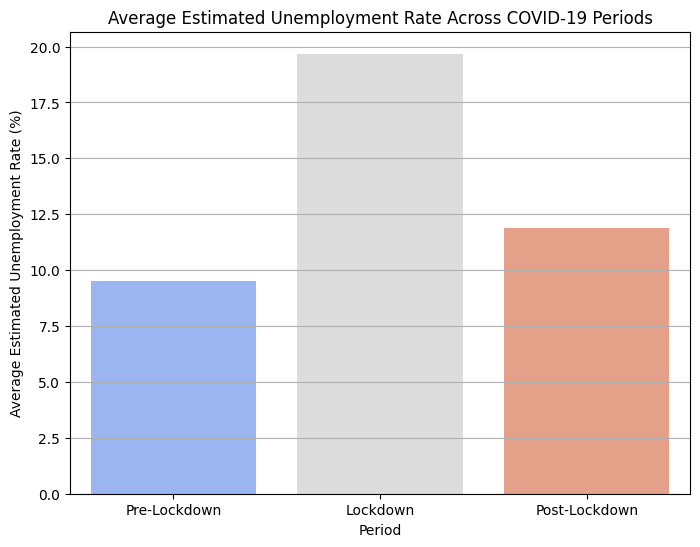

In [46]:
lockdown_start = pd.to_datetime('2020-03-24')
lockdown_end = pd.to_datetime('2020-05-31')
def categorize_period(date):
    if date < lockdown_start:
        return 'Pre-Lockdown'
    elif date >= lockdown_start and date <= lockdown_end:
        return 'Lockdown'
    else:
        return 'Post-Lockdown'

df['Period'] = df['Date'].apply(categorize_period)

avg_unemployment_by_period = df.groupby('Period')['Estimated Unemployment Rate (%)'].mean().reindex(['Pre-Lockdown', 'Lockdown', 'Post-Lockdown'])
display(avg_unemployment_by_period)

plt.figure(figsize=(8, 6))
sns.barplot(x=avg_unemployment_by_period.index, y=avg_unemployment_by_period.values, hue=avg_unemployment_by_period.index, palette='coolwarm', legend=False)
plt.title('Average Estimated Unemployment Rate Across COVID-19 Periods')
plt.xlabel('Period')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.grid(axis='y')
plt.show()

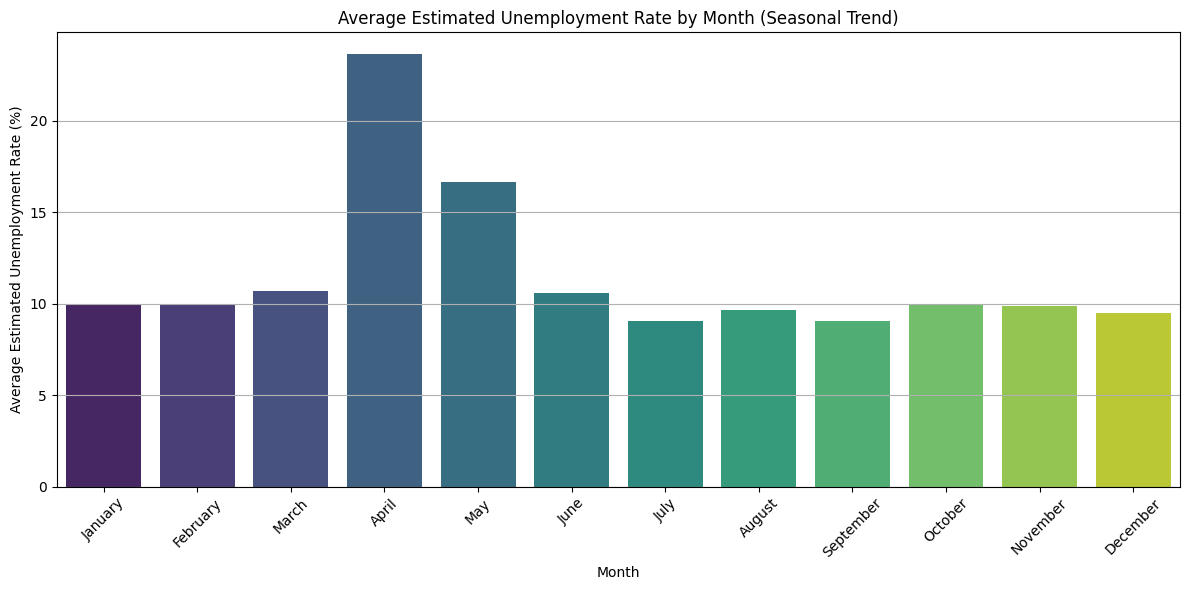

In [47]:
df['Month'] = df['Date'].dt.month_name()

avg_unemployment_month = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])


plt.figure(figsize=(12, 6))
sns.barplot(x=avg_unemployment_month.index, y=avg_unemployment_month.values, hue=avg_unemployment_month.index, palette='viridis', legend=False)
plt.title('Average Estimated Unemployment Rate by Month (Seasonal Trend)')
plt.xlabel('Month')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

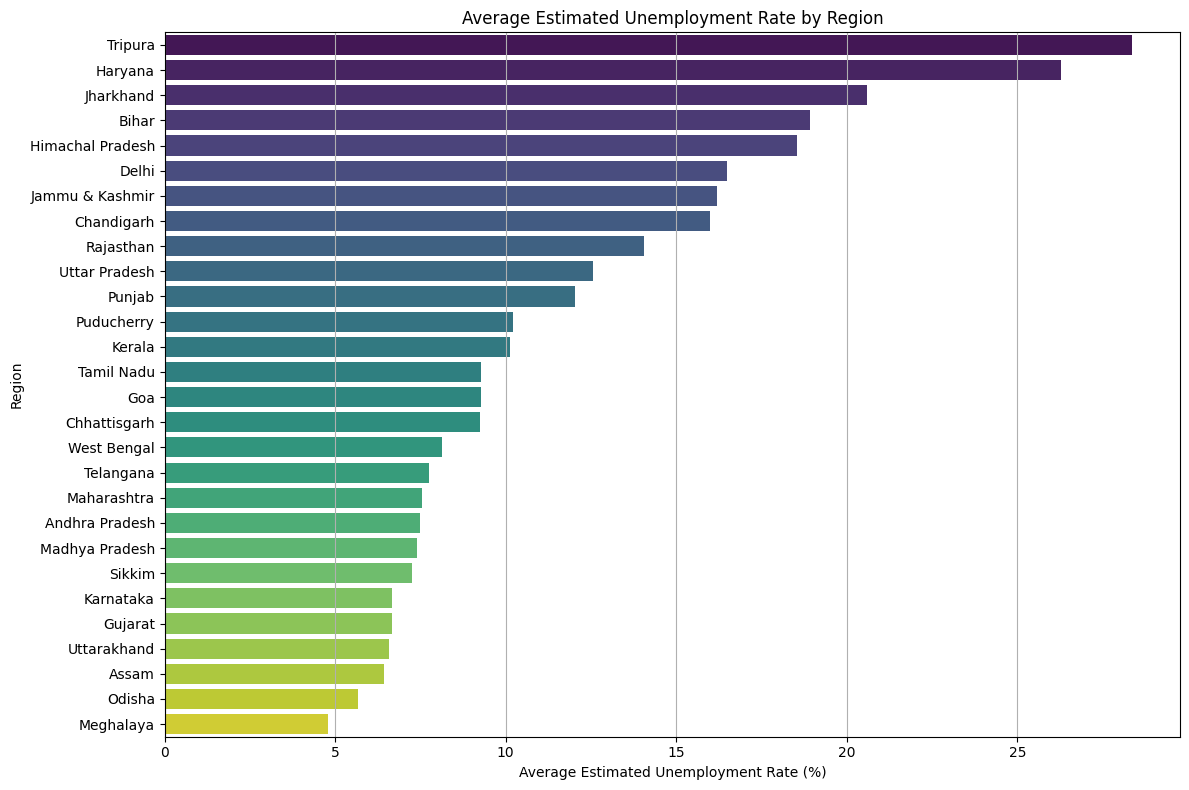

In [48]:
avg_unemployment_region = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=avg_unemployment_region.values, y=avg_unemployment_region.index, hue=avg_unemployment_region.index, palette='viridis', legend=False)
plt.title('Average Estimated Unemployment Rate by Region')
plt.xlabel('Average Estimated Unemployment Rate (%)')
plt.ylabel('Region')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [49]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Estimated Unemployment Rate (%)          740 non-null    float64       
 3   Estimated Employed                       740 non-null    float64       
 4   Estimated Labour Participation Rate (%)  740 non-null    float64       
 5   Period                                   740 non-null    object        
 6   Month                                    740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


None